In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)
print(f"Sample loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Sample loaded: 500,000 rows, 22 columns

Columns: ['Prscrbr_NPI', 'Prscrbr_Last_Org_Name', 'Prscrbr_First_Name', 'Prscrbr_City', 'Prscrbr_State_Abrvtn', 'Prscrbr_State_FIPS', 'Prscrbr_Type', 'Prscrbr_Type_Src', 'Brnd_Name', 'Gnrc_Name', 'Tot_Clms', 'Tot_30day_Fills', 'Tot_Day_Suply', 'Tot_Drug_Cst', 'Tot_Benes', 'GE65_Sprsn_Flag', 'GE65_Tot_Clms', 'GE65_Tot_30day_Fills', 'GE65_Tot_Drug_Cst', 'GE65_Tot_Day_Suply', 'GE65_Bene_Sprsn_Flag', 'GE65_Tot_Benes']


/var/folders/wx/slj5n9mx5_x5hpgtg68lnd_w0000gn/T/ipykernel_60188/916191343.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('MUP_DPR_RY26_P04_V10_DY24_NPIBN.csv', nrows=500000)


In [3]:
# Section 1: Top 10 prescribers by total drug cost — anonymized
top10 = (df.groupby('Prscrbr_NPI')['Tot_Drug_Cst']
           .sum()
           .reset_index()
           .sort_values('Tot_Drug_Cst', ascending=False)
           .head(10))

top10 = top10.reset_index(drop=True)
top10['Prescriber_ID'] = ['Prescriber-' + str(i+1).zfill(3) for i in range(len(top10))]
top10 = top10[['Prescriber_ID', 'Tot_Drug_Cst']].copy()
top10['Tot_Drug_Cst'] = top10['Tot_Drug_Cst'].round(2)

print("TOP 10 PRESCRIBERS BY TOTAL DRUG COST:")
display(top10)

TOP 10 PRESCRIBERS BY TOTAL DRUG COST:


,Prescriber_ID,Tot_Drug_Cst
0,Prescriber-001,41690176.03
1,Prescriber-002,17660241.43
2,Prescriber-003,14841387.65
3,Prescriber-004,13902581.59
4,Prescriber-005,13642124.74
5,Prescriber-006,12970420.06
6,Prescriber-007,12815139.91
7,Prescriber-008,11707871.27
8,Prescriber-009,9719040.72
9,Prescriber-010,9102070.46


In [4]:
# Section 2: Anomaly detection
spending_by_npi = df.groupby('Prscrbr_NPI')['Tot_Drug_Cst'].sum()

average   = spending_by_npi.mean()
std       = spending_by_npi.std()
threshold = average + 2 * std

print(f"Average spending per prescriber:  ${average:,.2f}")
print(f"Standard deviation:               ${std:,.2f}")
print(f"Anomaly threshold (mean+2σ):      ${threshold:,.2f}")

anomalies = spending_by_npi[spending_by_npi > threshold].reset_index()
anomalies = anomalies.sort_values('Tot_Drug_Cst', ascending=False).reset_index(drop=True)
anomalies['Prescriber_ID'] = ['Prescriber-' + str(i+1).zfill(3) for i in range(len(anomalies))]
anomalies = anomalies[['Prescriber_ID', 'Tot_Drug_Cst']]

print(f"\nAnomalous prescribers:  {len(anomalies):,}")
print(f"Share of total:         {len(anomalies)/len(spending_by_npi)*100:.1f}%")
display(anomalies.head(10))

Average spending per prescriber:  $196,534.89
Standard deviation:               $673,674.39
Anomaly threshold (mean+2σ):      $1,543,883.66

Anomalous prescribers:  510
Share of total:         2.4%


,Prescriber_ID,Tot_Drug_Cst
0,Prescriber-001,41690176.03
1,Prescriber-002,17660241.43
2,Prescriber-003,14841387.65
3,Prescriber-004,13902581.59
4,Prescriber-005,13642124.74
5,Prescriber-006,12970420.06
6,Prescriber-007,12815139.91
7,Prescriber-008,11707871.27
8,Prescriber-009,9719040.72
9,Prescriber-010,9102070.46


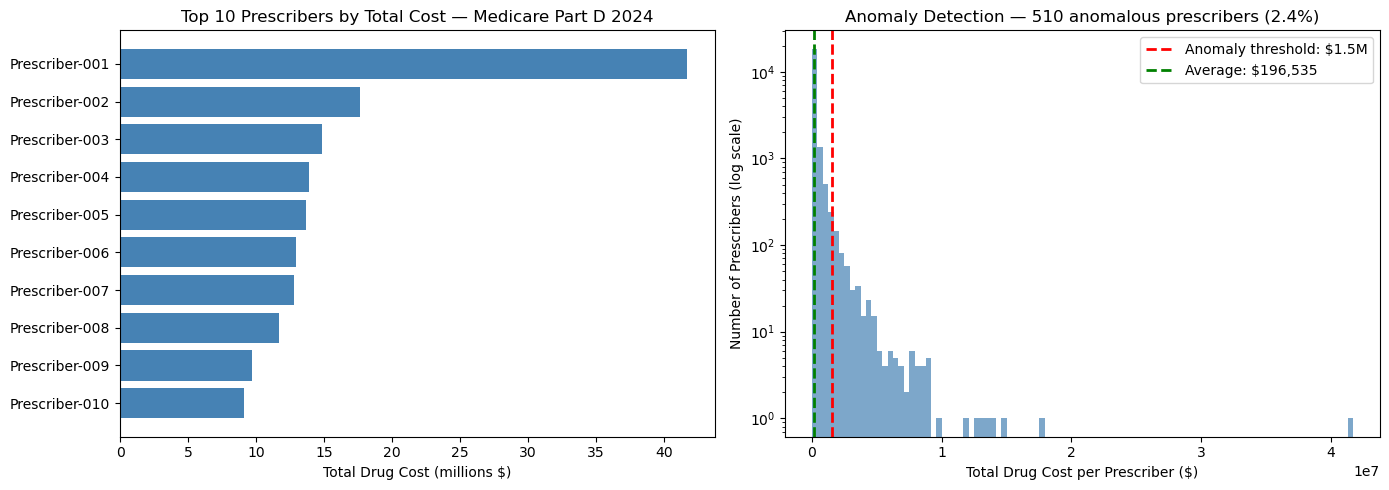

Chart saved ✅


In [5]:
# Section 3: Visualizations — anonymized
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    top10['Prescriber_ID'],
    top10['Tot_Drug_Cst'] / 1_000_000,
    color='steelblue'
)
axes[0].set_xlabel('Total Drug Cost (millions $)')
axes[0].set_title('Top 10 Prescribers by Total Cost — Medicare Part D 2024')
axes[0].invert_yaxis()

axes[1].hist(spending_by_npi, bins=100, color='steelblue', alpha=0.7, log=True)
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Anomaly threshold: ${threshold/1e6:.1f}M')
axes[1].axvline(average, color='green', linestyle='--', linewidth=2,
                label=f'Average: ${average:,.0f}')
axes[1].set_xlabel('Total Drug Cost per Prescriber ($)')
axes[1].set_ylabel('Number of Prescribers (log scale)')
axes[1].set_title(f'Anomaly Detection — {len(anomalies):,} anomalous prescribers (2.4%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('cms_anomaly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

In [6]:
print("=" * 58)
print("SUMMARY — CMS Medicare Part D Anomaly Analysis")
print("=" * 58)
print(f"Dataset:                  CMS Medicare Part D 2024")
print(f"Sample analyzed:          500,000 records")
print(f"Unique prescribers:       {len(spending_by_npi):,}")
print(f"Average spending:         ${average:,.2f}")
print(f"Anomaly threshold:        ${threshold:,.2f}")
print(f"Anomalous prescribers:    {len(anomalies):,} ({len(anomalies)/len(spending_by_npi)*100:.1f}%)")
print(f"Top outlier:              Prescriber-001 — ${anomalies.iloc[0]['Tot_Drug_Cst']:,.0f}")
print("=" * 58)
print("Analysis complete ✅")

SUMMARY — CMS Medicare Part D Anomaly Analysis
Dataset:                  CMS Medicare Part D 2024
Sample analyzed:          500,000 records
Unique prescribers:       21,025
Average spending:         $196,534.89
Anomaly threshold:        $1,543,883.66
Anomalous prescribers:    510 (2.4%)
Top outlier:              Prescriber-001 — $41,690,176
Analysis complete ✅
